<a href="https://colab.research.google.com/github/NelvaAdalit/Machine-Learning-SIS420-Datasets/blob/main/04_Bike_Sharing_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚲 Dataset 04: Bike Sharing Demand

## 📋 Descripción del Dataset
Este dataset contiene el registro histórico del uso de bicicletas compartidas en la ciudad de Washington, D.C. Combina datos de tiempo con indicadores climáticos.
* **Archivo utilizado:** `train.csv`.
* **Objetivo:** Predecir la demanda total de alquileres (`count`) basándose en el clima y la temporalidad.
* **Dimensiones:** 10,886 filas y 12 columnas originales.

## 🛠️ Archivos en esta carpeta
* `train.csv`: Dataset original con datos de demanda.
* `04_Bike_Sharing_Analysis.ipynb`: Cuaderno de Colab con ingeniería de características y preparación.

## ⚙️ Trabajo y Preparación de Datos
1. **Ingeniería de Tiempos:** Se descompuso la columna `datetime` en cuatro nuevas variables numéricas: `hour`, `day`, `month` y `year`.
2. **Selección de Características:** Se eliminaron las columnas `casual` y `registered`, ya que su suma directa constituye el valor de `count`, lo que causaría una fuga de datos (*data leakage*).
3. **Tratamiento de Nulos:** Aunque el dataset suele venir completo, se aplicó un protocolo de imputación por media y moda como medida de seguridad.
4. **Normalización:** Se aplicó normalización Z-Score manual para igualar las escalas de variables como temperatura (Celsius) y humedad (porcentaje).

## 📊 Hallazgos Visuales
La gráfica de dispersión muestra una correlación clara: a medida que la temperatura aumenta (hasta un punto óptimo), la demanda de bicicletas también crece, validando la importancia de las variables climáticas en el modelo.

---
*Preparación realizada para la Primera Parte del Examen Parcial.*

In [10]:
# ==============================================================================
# 1. CONEXIÓN Y LIBRERÍAS
# ==============================================================================
from google.colab import drive
drive.mount('/content/gdrive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)
print("Librerías cargadas correctamente.")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Librerías cargadas correctamente.


In [11]:
# ==============================================================================
# 2. CARGA DE DATOS E INGENIERÍA DE CARACTERÍSTICAS
# ==============================================================================
# Ruta de tu archivo train.csv
ruta_bike = '/content/gdrive/MyDrive/Machine-Learning-SIS420-Datasets/04_Bike Sharing/train.csv'

df = pd.read_csv(ruta_bike)

# PASO CLAVE: Convertimos 'datetime' a formato fecha y extraemos componentes numéricos
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['year'] = df['datetime'].dt.year

# Eliminamos la columna original 'datetime' (porque ya es texto inservible)
# También eliminamos 'casual' y 'registered' porque su suma es igual a 'count'
df = df.drop(['datetime', 'casual', 'registered'], axis=1)

print("="*70)
print(f"DATASET BIKE SHARING PREPARADO: {df.shape[0]} filas y {df.shape[1]} columnas")
print("Objetivo (y): 'count' (Total de alquileres)")
print("="*70)
display(df.head(3))

DATASET BIKE SHARING PREPARADO: 10886 filas y 13 columnas
Objetivo (y): 'count' (Total de alquileres)


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,hour,day,month,year
0,1,0,0,1,9.84,14.395,81,0.0,16,0,1,1,2011
1,1,0,0,1,9.02,13.635,80,0.0,40,1,1,1,2011
2,1,0,0,1,9.02,13.635,80,0.0,32,2,1,1,2011


In [12]:
# ==============================================================================
# 3. ANTES Y DESPUÉS: TRATAMIENTO DE NULOS
# ==============================================================================
print("="*70)
print(" FASE 1: TRATAMIENTO DE VALORES NULOS")
print("="*70)

nulos_antes = df.isnull().sum().sum()
print(f"\n🔴 [ANTES] Total de valores nulos: {nulos_antes}")

# Proceso estándar de limpieza
for columna in df.columns:
    if df[columna].dtype == 'object':
        df[columna] = df[columna].fillna(df[columna].mode()[0])
    else:
        df[columna] = df[columna].fillna(df[columna].mean())

print(f"🟢 [DESPUÉS] Total de nulos restantes: {df.isnull().sum().sum()} ✅")

 FASE 1: TRATAMIENTO DE VALORES NULOS

🔴 [ANTES] Total de valores nulos: 0
🟢 [DESPUÉS] Total de nulos restantes: 0 ✅


### 4. Diccionario de Variables y Transformación Temporal
Este dataset combina factores climáticos y temporales para predecir la demanda de alquiler. Se realizará ingeniería de características sobre la columna de tiempo para capturar patrones horarios:

* **datetime**: Marca de tiempo original (Año-Mes-Día Hora:Min:Seg).
* **season**: Estación del año (1: Primavera, 2: Verano, 3: Otoño, 4: Invierno).
* **holiday**: Indica si el día es considerado feriado (1: Sí, 0: No).
* **workingday**: Indica si el día no es ni fin de semana ni feriado (1: Sí, 0: No).
* **weather**: Condición climática (1: Despejado, 2: Niebla/Nubes, 3: Lluvia/Nieve ligera, 4: Clima extremo).
* **temp / atemp**: Temperatura real y sensación térmica en grados Celsius.
* **humidity**: Porcentaje de humedad relativa.
* **windspeed**: Velocidad del viento.
* **count (Target)**: Cantidad total de bicicletas alquiladas en esa hora.

In [13]:
# ==============================================================================
# 4. ANTES Y DESPUÉS: INGENIERÍA DE TIEMPOS Y LIMPIEZA (50 FILAS)
# ==============================================================================
print("="*80)
print(" FASE 2: DESGLOSE TEMPORAL Y ELIMINACIÓN DE FUGA DE DATOS (DATA LEAKAGE)")
print("="*80)

# Configuramos visualización de 50 filas
pd.set_option('display.max_rows', 50)

# ------------------------------------------------------------------------------
# ANTES: Datos crudos con la columna datetime original
# ------------------------------------------------------------------------------
print("\n🔴 [ANTES] Estructura del dataset después de ingeniería de tiempos inicial y eliminación de columnas:")
print("Se muestran las primeras 50 filas para revisión:")
display(df.head(50))

# PROCESO: Ingeniería de Características (Feature Engineering) - ESTE BLOQUE ES REDUNDANTE
#          ya que las operaciones se realizaron en la celda '2. CARGA DE DATOS E INGENIERÍA DE CARACTERÍSTICAS'.
# df['datetime'] = pd.to_datetime(df['datetime'])
# df['hour'] = df['datetime'].dt.hour
# df['day'] = df['datetime'].dt.day
# df['month'] = df['datetime'].dt.month
# df['year'] = df['datetime'].dt.year

# Eliminamos columnas que no se usarán o que causan Data Leakage (casual + registered = count) - ESTO TAMBIÉN ES REDUNDANTE.
# df_final = df.drop(['datetime', 'casual', 'registered'], axis=1)

# Para mostrar el estado 'DESPUÉS' sin cambios adicionales en esta fase:
df_final = df.copy()

# ------------------------------------------------------------------------------
# DESPUÉS: Datos listos con nuevas columnas numéricas
# ------------------------------------------------------------------------------
print("\n🟢 [DESPUÉS] Dataset con la ingeniería de tiempos ya aplicada (sin cambios en esta fase):")
print("Las columnas 'casual' y 'registered' fueron eliminadas previamente para evitar sesgos en el modelo.")
display(df_final.head(50))

# Restauramos la configuración
pd.reset_option('display.max_rows')
df = df_final.copy()

 FASE 2: DESGLOSE TEMPORAL Y ELIMINACIÓN DE FUGA DE DATOS (DATA LEAKAGE)

🔴 [ANTES] Estructura del dataset después de ingeniería de tiempos inicial y eliminación de columnas:
Se muestran las primeras 50 filas para revisión:


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,hour,day,month,year
0,1,0,0,1,9.84,14.395,81,0.0000,16,0,1,1,2011
1,1,0,0,1,9.02,13.635,80,0.0000,40,1,1,1,2011
2,1,0,0,1,9.02,13.635,80,0.0000,32,2,1,1,2011
3,1,0,0,1,9.84,14.395,75,0.0000,13,3,1,1,2011
4,1,0,0,1,9.84,14.395,75,0.0000,1,4,1,1,2011
5,1,0,0,2,9.84,12.880,75,6.0032,1,5,1,1,2011
6,1,0,0,1,9.02,13.635,80,0.0000,2,6,1,1,2011
7,1,0,0,1,8.20,12.880,86,0.0000,3,7,1,1,2011
8,1,0,0,1,9.84,14.395,75,0.0000,8,8,1,1,2011
9,1,0,0,1,13.12,17.425,76,0.0000,14,9,1,1,2011



🟢 [DESPUÉS] Dataset con la ingeniería de tiempos ya aplicada (sin cambios en esta fase):
Las columnas 'casual' y 'registered' fueron eliminadas previamente para evitar sesgos en el modelo.


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,hour,day,month,year
0,1,0,0,1,9.84,14.395,81,0.0000,16,0,1,1,2011
1,1,0,0,1,9.02,13.635,80,0.0000,40,1,1,1,2011
2,1,0,0,1,9.02,13.635,80,0.0000,32,2,1,1,2011
3,1,0,0,1,9.84,14.395,75,0.0000,13,3,1,1,2011
4,1,0,0,1,9.84,14.395,75,0.0000,1,4,1,1,2011
5,1,0,0,2,9.84,12.880,75,6.0032,1,5,1,1,2011
6,1,0,0,1,9.02,13.635,80,0.0000,2,6,1,1,2011
7,1,0,0,1,8.20,12.880,86,0.0000,3,7,1,1,2011
8,1,0,0,1,9.84,14.395,75,0.0000,8,8,1,1,2011
9,1,0,0,1,13.12,17.425,76,0.0000,14,9,1,1,2011


In [14]:
# ==============================================================================
# 5. MATRIZ FINAL Y NORMALIZACIÓN (Z-Score)
# ==============================================================================
# Separamos X (características) y y (count)
X = df.drop('count', axis=1).values
y = df['count'].values

def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_norm, mu, sigma = featureNormalize(X)

print("="*70)
print("¡MATRIZ X_norm CREADA EXITOSAMENTE!")
print(f"Forma de X_norm: {X_norm.shape}")
print("="*70)

¡MATRIZ X_norm CREADA EXITOSAMENTE!
Forma de X_norm: (10886, 12)


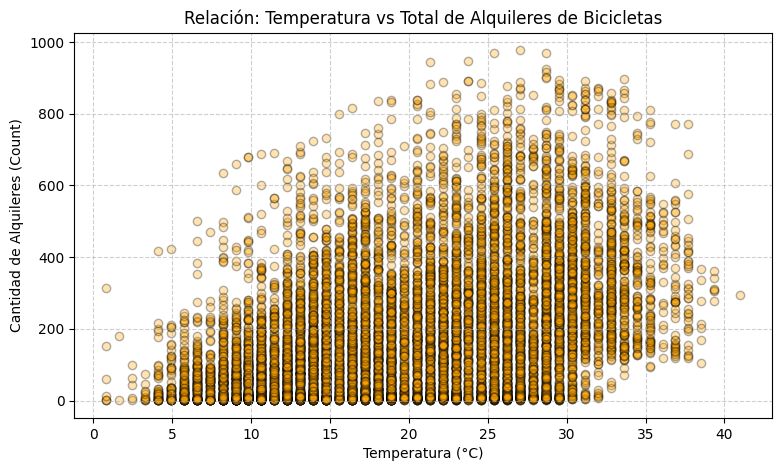

In [15]:
# ==============================================================================
# 6. VISUALIZACIÓN EXPLORATORIA
# ==============================================================================
plt.figure(figsize=(9, 5))
plt.scatter(df['temp'], df['count'], alpha=0.3, c='orange', edgecolors='k')
plt.title('Relación: Temperatura vs Total de Alquileres de Bicicletas')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Cantidad de Alquileres (Count)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()